# COMP 3610 Assignment 3  
## LLM-Powered Applications & Distributed Computing

**Name:** Runako Stubbs
**ID:** 816036195
**Course:** COMP 3610: Big Data Analytics  

## 0. Environment Setup

This section installs the libraries required for Spark processing, document ingestion, embeddings, vector storage, and LLM access.  
The assignment deliverables require PySpark, LangChain/PyPDF document loading, ChromaDB persistence, sentence-transformer embeddings, and an OpenAI-compatible client.

In [8]:
# Uncomment this cell if you need to install packages locally
# !pip install pyspark pandas matplotlib seaborn numpy pypdf langchain langchain-community \
#   langchain-text-splitters chromadb sentence-transformers openai

In [ ]:
import os
import re
import json
import time
import math
import textwrap
import urllib.request
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pypdf import PdfReader
from langchain_community.document_loaders import PyPDFDirectoryLoader

RANDOM_STATE = 42
DATA_DIR = Path("data")
DOCS_DIR = Path("docs")
OUTPUT_DIR = Path("output")
CHROMA_DIR = Path("chroma_db")

for path in [DATA_DIR, DOCS_DIR, OUTPUT_DIR, CHROMA_DIR]:
    path.mkdir(parents=True, exist_ok=True)

CSV_SOURCE_PATH = Path("cleaned_taxi_data.csv")  # place the uploaded CSV beside this notebook
assert CSV_SOURCE_PATH.exists(), "Place cleaned_taxi_data.csv in the same folder as this notebook."
print("Setup complete.")

Setup complete.


## Part 1: Distributed Data Processing with Spark

- a SparkSession with suitable configuration,
- data loading with schema, row count, and partition count,
- Spark-based cleaning and feature engineering,
- five Spark SQL analytics queries,
- caching, partitioned Parquet output, partition pruning, and execution-plan analysis.【24:0†COMP3610_Assignment3 (4).pdf†L2-L5】

The structure below follows Lab 7 closely, including local Spark setup, DataFrame operations, Spark SQL, and optimization steps.【13:COMP3610_Lab7_Distributed_Data_Processing_with_Spark.pdf†L21-L22】

### Task 1.1 — Spark Environment Setup & Data Loading



First, It seems as if Pyspark does not work with JDK version 23. To ensure no problems, i will integrate a new cell that forces it no matter who is running this notebook.

In [ ]:
os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-17"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

In [11]:
os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-17"
os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["hadoop.home.dir"] = r"C:\hadoop"
os.environ["PATH"] = r"C:\Program Files\Java\jdk-17\bin;C:\hadoop\bin;" + os.environ["PATH"]

print("JAVA_HOME =", os.environ.get("JAVA_HOME"))
print("HADOOP_HOME =", os.environ.get("HADOOP_HOME"))
print("hadoop.home.dir =", os.environ.get("hadoop.home.dir"))
print("winutils exists =", os.path.exists(r"C:\hadoop\bin\winutils.exe"))

JAVA_HOME = C:\Program Files\Java\jdk-17
HADOOP_HOME = C:\hadoop
hadoop.home.dir = C:\hadoop
winutils exists = True


In [12]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.sql.types import (
    StructType, StructField, IntegerType, DoubleType, StringType, TimestampType
)

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("COMP3610_Assignment3")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

print(f"Spark version: {spark.version}")
print(f"App name: {spark.sparkContext.appName}")
print(f"Master: {spark.sparkContext.master}")
print(f"Default parallelism: {spark.sparkContext.defaultParallelism}")
print("Spark UI: http://localhost:4040")

Spark version: 4.1.1
App name: COMP3610_Assignment3
Master: local[*]
Default parallelism: 16
Spark UI: http://localhost:4040


In [13]:
# Compare Spark CSV load time against Pandas load time
start_spark = time.time()
df_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(str(CSV_SOURCE_PATH))
)
# Trigger execution
raw_count = df_raw.count()
spark_load_time = time.time() - start_spark

start_pandas = time.time()
pdf = pd.read_csv(CSV_SOURCE_PATH, low_memory=False)
pandas_load_time = time.time() - start_pandas

print(f"Spark load + count time: {spark_load_time:.2f} seconds")
print(f"Pandas load time: {pandas_load_time:.2f} seconds")
print(f"Row count: {raw_count:,}")
print(f"Column count: {len(df_raw.columns)}")
print(f"Partition count: {df_raw.rdd.getNumPartitions()}")

Spark load + count time: 7.15 seconds
Pandas load time: 8.19 seconds
Row count: 2,870,102
Column count: 23
Partition count: 16


In [14]:
df_raw.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- trip_duration_minutes: integer (nullable = true)
 |-- average_speed_mph: string (nullable = true)
 |-- pickup_hour: inte

In [15]:
df_raw.show(5, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+---------------------+-------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|trip_duration_minutes|average_speed_mph  |pickup_hour|pickup_day_of_week|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+---------------------+-------------------+

**Spark vs. Pandas Load Time Comparison**

Spark completed a full load and row count of the 2,870,102-row dataset in approximately **6.82 seconds**, while Pandas read the same CSV in **7.99 seconds** — making Spark marginally faster here. This may seem surprising, since Spark typically has higher startup overhead. The result makes sense for this file size: Spark spread the parse across all 16 available CPU cores (matching the default parallelism of 16), whereas Pandas is single-threaded. As dataset size scales beyond available RAM, Spark's distributed model would widen this advantage dramatically, while Pandas would begin to struggle or fail. For in-memory workloads on a single machine, Pandas is usually faster; the real payoff for Spark appears at sizes that require cluster distribution or exceed driver memory.

### Task 1.2 — Data Cleaning & Feature Engineering in Spark

The assignment requires null removal for critical columns, invalid-trip filtering, derived columns for duration, speed, pickup hour, day of week, and tip percentage, plus counts removed at each step.

Because the provided dataset is already cleaned, this section **re-validates** and **rebuilds/standardizes** the required fields in Spark so the workflow still matches the rubric.

In [16]:
critical_columns = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "PULocationID", "DOLocationID",
    "fare_amount", "trip_distance"
]

# Standardize timestamp columns
df1 = (
    df_raw
    .withColumn("tpep_pickup_datetime", F.to_timestamp("tpep_pickup_datetime"))
    .withColumn("tpep_dropoff_datetime", F.to_timestamp("tpep_dropoff_datetime"))
)

count_initial = df1.count()

# Step 1: remove nulls from critical columns
df2 = df1.dropna(subset=critical_columns)
count_after_nulls = df2.count()
removed_nulls = count_initial - count_after_nulls

# Step 2: filter invalid trips
df3 = df2.filter(
    (F.col("trip_distance") > 0) &
    (F.col("fare_amount") >= 0) &
    (F.col("fare_amount") <= 500) &
    (F.col("tpep_dropoff_datetime") >= F.col("tpep_pickup_datetime"))
)
count_after_invalid = df3.count()
removed_invalid = count_after_nulls - count_after_invalid

# Step 3: rebuild required derived columns
duration_minutes_expr = (
    (F.col("tpep_dropoff_datetime").cast("long") - F.col("tpep_pickup_datetime").cast("long")) / 60.0
)

df_clean = (
    df3
    .withColumn("trip_duration_minutes", duration_minutes_expr)
    .withColumn(
        "trip_speed_mph",
        F.when(duration_minutes_expr > 0, F.col("trip_distance") / (duration_minutes_expr / 60.0))
         .otherwise(F.lit(None).cast("double"))
    )
    .withColumn("pickup_hour", F.hour("tpep_pickup_datetime"))
    .withColumn("pickup_day_of_week_num", F.dayofweek("tpep_pickup_datetime"))
    .withColumn(
        "tip_percentage",
        F.when(F.col("fare_amount") > 0, (F.col("tip_amount") / F.col("fare_amount")) * 100.0)
         .otherwise(F.lit(None).cast("double"))
    )
)

print(f"Initial rows: {count_initial:,}")
print(f"Rows removed for null critical values: {removed_nulls:,}")
print(f"Rows removed for invalid trip rules: {removed_invalid:,}")
print(f"Final cleaned rows: {df_clean.count():,}")

Initial rows: 2,870,102
Rows removed for null critical values: 0
Rows removed for invalid trip rules: 0
Final cleaned rows: 2,870,102


In [17]:
df_clean.select(
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_distance",
    "fare_amount",
    "trip_duration_minutes",
    "trip_speed_mph",
    "pickup_hour",
    "pickup_day_of_week_num",
    "tip_percentage"
).show(10, truncate=False)

+--------------------+---------------------+-------------+-----------+---------------------+------------------+-----------+----------------------+------------------+
|tpep_pickup_datetime|tpep_dropoff_datetime|trip_distance|fare_amount|trip_duration_minutes|trip_speed_mph    |pickup_hour|pickup_day_of_week_num|tip_percentage    |
+--------------------+---------------------+-------------+-----------+---------------------+------------------+-----------+----------------------+------------------+
|2024-01-01 00:57:55 |2024-01-01 01:17:43  |1.72         |17.7       |19.8                 |5.212121212121212 |0          |2                     |0.0               |
|2024-01-01 00:03:00 |2024-01-01 00:09:36  |1.8          |10.0       |6.6                  |16.363636363636363|0          |2                     |37.5              |
|2024-01-01 00:17:06 |2024-01-01 00:35:01  |4.7          |23.3       |17.916666666666668   |15.739534883720932|0          |2                     |12.875536480686694|
|202

**Cleaning Summary**

Zero rows were removed at either cleaning step — no nulls were found in the six critical columns, and no trips violated the validity rules (zero or negative distance, negative fares, fares above \$500, or dropoff before pickup). This is expected: the source file is named `cleaned_taxi_data.csv`, meaning upstream preprocessing already handled these cases. The Spark cleaning pipeline still serves a meaningful purpose here: it **re-validates** the data within the Spark execution environment, rebuilds all required derived columns (`trip_duration_minutes`, `trip_speed_mph`, `pickup_hour`, `pickup_day_of_week_num`, `tip_percentage`) using Spark functions with proper edge-case handling (e.g., division-by-zero guards), and confirms that the dataset is safe for all downstream SQL queries.

### Task 1.3 — Spark SQL Analytics

The assignment specifies five Spark SQL queries and asks for a 1–2 sentence interpretation after each result.

In [18]:
df_clean.createOrReplaceTempView("taxi_trips")
print("Temporary SQL view 'taxi_trips' registered.")

Temporary SQL view 'taxi_trips' registered.


In [19]:
def run_sql(title: str, query: str, limit_show: int = 20):
    print("=" * 100)
    print(title)
    print("-" * 100)
    print(query)
    result = spark.sql(query)
    result.show(limit_show, truncate=False)
    return result

In [20]:
query1 = '''
SELECT
    pickup_hour,
    COUNT(*) AS trip_count,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(tip_percentage), 2) AS avg_tip_percentage
FROM taxi_trips
GROUP BY pickup_hour
ORDER BY trip_count DESC
LIMIT 10
'''
q1_result = run_sql("Query 1: Top 10 busiest pickup hours", query1)

Query 1: Top 10 busiest pickup hours
----------------------------------------------------------------------------------------------------

SELECT
    pickup_hour,
    COUNT(*) AS trip_count,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(tip_percentage), 2) AS avg_tip_percentage
FROM taxi_trips
GROUP BY pickup_hour
ORDER BY trip_count DESC
LIMIT 10

+-----------+----------+--------+------------------+
|pickup_hour|trip_count|avg_fare|avg_tip_percentage|
+-----------+----------+--------+------------------+
|18         |206284    |17.01   |22.78             |
|17         |200315    |18.12   |22.34             |
|16         |184971    |19.46   |21.84             |
|15         |184009    |19.11   |19.8              |
|19         |178812    |17.63   |22.86             |
|14         |178031    |19.27   |19.8              |
|13         |165361    |18.42   |19.79             |
|12         |159916    |17.8    |19.74             |
|21         |155915    |18.29   |21.88             |
|

**Query 1 Interpretation**

The top five busiest pickup hours are all in the evening commute window: **6 PM leads with 206,284 trips**, followed by 5 PM (200,315), 4 PM (184,971), 3 PM (184,009), and 7 PM (178,812). This strongly reflects end-of-workday demand in a dense urban environment. Notably, the busiest hours also carry **competitive average fares** (\$17–\$19) and the **highest tip percentages in the dataset** (~22–23%). Passengers hailing cabs during rush hour appear to tip proportionally more than midday riders, possibly reflecting business-expense trips or a higher share of longer, fare-metered rides where tipping becomes habitual.

In [21]:
query2 = '''
SELECT
    pickup_day_of_week_num,
    CASE pickup_day_of_week_num
        WHEN 1 THEN 'Sunday'
        WHEN 2 THEN 'Monday'
        WHEN 3 THEN 'Tuesday'
        WHEN 4 THEN 'Wednesday'
        WHEN 5 THEN 'Thursday'
        WHEN 6 THEN 'Friday'
        WHEN 7 THEN 'Saturday'
    END AS pickup_day_name,
    ROUND(AVG(trip_speed_mph), 2) AS avg_trip_speed_mph,
    ROUND(AVG(trip_distance), 2) AS avg_distance,
    ROUND(AVG(trip_duration_minutes), 2) AS avg_duration_minutes
FROM taxi_trips
WHERE trip_speed_mph IS NOT NULL
GROUP BY pickup_day_of_week_num
ORDER BY avg_trip_speed_mph DESC
'''
q2_result = run_sql("Query 2: Day with highest average trip speed", query2)

Query 2: Day with highest average trip speed
----------------------------------------------------------------------------------------------------

SELECT
    pickup_day_of_week_num,
    CASE pickup_day_of_week_num
        WHEN 1 THEN 'Sunday'
        WHEN 2 THEN 'Monday'
        WHEN 3 THEN 'Tuesday'
        WHEN 4 THEN 'Wednesday'
        WHEN 5 THEN 'Thursday'
        WHEN 6 THEN 'Friday'
        WHEN 7 THEN 'Saturday'
    END AS pickup_day_name,
    ROUND(AVG(trip_speed_mph), 2) AS avg_trip_speed_mph,
    ROUND(AVG(trip_distance), 2) AS avg_distance,
    ROUND(AVG(trip_duration_minutes), 2) AS avg_duration_minutes
FROM taxi_trips
WHERE trip_speed_mph IS NOT NULL
GROUP BY pickup_day_of_week_num
ORDER BY avg_trip_speed_mph DESC

+----------------------+---------------+------------------+------------+--------------------+
|pickup_day_of_week_num|pickup_day_name|avg_trip_speed_mph|avg_distance|avg_duration_minutes|
+----------------------+---------------+------------------+------------+

**Query 2 Interpretation**

**Tuesday has the highest average trip speed at 17.46 mph**, followed by Sunday (15.97 mph) and Monday (13.85 mph). Wednesday and Thursday are the slowest, both averaging around 12–12.5 mph. Tuesday's elevated speed is likely explained by lighter midweek road congestion — the initial wave of Monday commuters has tapered off, and the Friday/weekend traffic buildup has not yet begun. Sunday's second-place ranking aligns with reduced commercial and commuter traffic on the roads. Interestingly, Tuesday trips are also the longest on average (4.25 miles vs. 3.39 miles on Saturday), yet they complete faster — reinforcing that road conditions, not distance, are the primary driver of speed variance.

In [22]:
query3 = '''
WITH revenue_by_location AS (
    SELECT
        pickup_day_of_week_num,
        PULocationID,
        ROUND(SUM(total_amount), 2) AS total_revenue
    FROM taxi_trips
    GROUP BY pickup_day_of_week_num, PULocationID
),
ranked AS (
    SELECT
        pickup_day_of_week_num,
        PULocationID,
        total_revenue,
        ROW_NUMBER() OVER (
            PARTITION BY pickup_day_of_week_num
            ORDER BY total_revenue DESC
        ) AS revenue_rank
    FROM revenue_by_location
)
SELECT *
FROM ranked
WHERE revenue_rank <= 5
ORDER BY pickup_day_of_week_num, revenue_rank
'''
q3_result = run_sql("Query 3: Top 5 pickup locations by revenue for each day", query3, limit_show=50)

Query 3: Top 5 pickup locations by revenue for each day
----------------------------------------------------------------------------------------------------

WITH revenue_by_location AS (
    SELECT
        pickup_day_of_week_num,
        PULocationID,
        ROUND(SUM(total_amount), 2) AS total_revenue
    FROM taxi_trips
    GROUP BY pickup_day_of_week_num, PULocationID
),
ranked AS (
    SELECT
        pickup_day_of_week_num,
        PULocationID,
        total_revenue,
        ROW_NUMBER() OVER (
            PARTITION BY pickup_day_of_week_num
            ORDER BY total_revenue DESC
        ) AS revenue_rank
    FROM revenue_by_location
)
SELECT *
FROM ranked
WHERE revenue_rank <= 5
ORDER BY pickup_day_of_week_num, revenue_rank

+----------------------+------------+-------------+------------+
|pickup_day_of_week_num|PULocationID|total_revenue|revenue_rank|
+----------------------+------------+-------------+------------+
|1                     |132         |1564287.93   |1         

**Query 3 Interpretation**

**Location 132 (JFK Airport) dominates revenue across every single day of the week**, generating between \$1.28M (Saturday) and \$2.05M (Monday) in total fares per weekday — consistently ranking #1. Location 138 (LaGuardia Airport) holds #2 every day. This persistence confirms that airport pickups are the single largest revenue source in the NYC Yellow Taxi dataset, driven by long trip distances and higher flat-rate or metered fares. Mid-week days (Monday–Wednesday) see higher airport revenues, consistent with business travel patterns. On weekends, locations 230 and 249 (likely Penn Station and Times Square areas) replace the Midtown cluster in the top 5, reflecting the shift from commuter to leisure travel.

In [23]:
query4 = '''
WITH hourly_counts AS (
    SELECT
        pickup_hour,
        COUNT(*) AS trip_count
    FROM taxi_trips
    GROUP BY pickup_hour
),
ordered AS (
    SELECT
        pickup_hour,
        trip_count,
        SUM(trip_count) OVER (ORDER BY pickup_hour) AS cumulative_trip_count,
        SUM(trip_count) OVER () AS total_trip_count
    FROM hourly_counts
)
SELECT
    pickup_hour,
    trip_count,
    cumulative_trip_count,
    total_trip_count,
    ROUND(cumulative_trip_count * 100.0 / total_trip_count, 2) AS cumulative_pct
FROM ordered
ORDER BY pickup_hour
'''
q4_result = run_sql("Query 4: Cumulative trip count by hour", query4, limit_show=24)

Query 4: Cumulative trip count by hour
----------------------------------------------------------------------------------------------------

WITH hourly_counts AS (
    SELECT
        pickup_hour,
        COUNT(*) AS trip_count
    FROM taxi_trips
    GROUP BY pickup_hour
),
ordered AS (
    SELECT
        pickup_hour,
        trip_count,
        SUM(trip_count) OVER (ORDER BY pickup_hour) AS cumulative_trip_count,
        SUM(trip_count) OVER () AS total_trip_count
    FROM hourly_counts
)
SELECT
    pickup_hour,
    trip_count,
    cumulative_trip_count,
    total_trip_count,
    ROUND(cumulative_trip_count * 100.0 / total_trip_count, 2) AS cumulative_pct
FROM ordered
ORDER BY pickup_hour

+-----------+----------+---------------------+----------------+--------------+
|pickup_hour|trip_count|cumulative_trip_count|total_trip_count|cumulative_pct|
+-----------+----------+---------------------+----------------+--------------+
|0          |75251     |75251                |2870102         

In [24]:
query4_half = '''
WITH hourly_counts AS (
    SELECT
        pickup_hour,
        COUNT(*) AS trip_count
    FROM taxi_trips
    GROUP BY pickup_hour
),
ordered AS (
    SELECT
        pickup_hour,
        trip_count,
        SUM(trip_count) OVER (ORDER BY pickup_hour) AS cumulative_trip_count,
        SUM(trip_count) OVER () AS total_trip_count
    FROM hourly_counts
)
SELECT
    pickup_hour,
    trip_count,
    cumulative_trip_count,
    total_trip_count,
    ROUND(cumulative_trip_count * 100.0 / total_trip_count, 2) AS cumulative_pct
FROM ordered
WHERE cumulative_trip_count >= total_trip_count * 0.5
ORDER BY pickup_hour
LIMIT 1
'''
q4_half_result = run_sql("Hour where cumulative trips first surpass 50%", query4_half)

Hour where cumulative trips first surpass 50%
----------------------------------------------------------------------------------------------------

WITH hourly_counts AS (
    SELECT
        pickup_hour,
        COUNT(*) AS trip_count
    FROM taxi_trips
    GROUP BY pickup_hour
),
ordered AS (
    SELECT
        pickup_hour,
        trip_count,
        SUM(trip_count) OVER (ORDER BY pickup_hour) AS cumulative_trip_count,
        SUM(trip_count) OVER () AS total_trip_count
    FROM hourly_counts
)
SELECT
    pickup_hour,
    trip_count,
    cumulative_trip_count,
    total_trip_count,
    ROUND(cumulative_trip_count * 100.0 / total_trip_count, 2) AS cumulative_pct
FROM ordered
WHERE cumulative_trip_count >= total_trip_count * 0.5
ORDER BY pickup_hour
LIMIT 1

+-----------+----------+---------------------+----------------+--------------+
|pickup_hour|trip_count|cumulative_trip_count|total_trip_count|cumulative_pct|
+-----------+----------+---------------------+----------------+---------

**Query 4 Interpretation**

Cumulative trip volume crosses the **50% mark at hour 15 (3 PM)**, at which point 1,545,359 of the 2,870,102 daily trips have occurred — representing 53.84% of the day's rides. This reveals a strongly right-skewed intraday distribution: the first 15 hours of the day (midnight through 2 PM) account for only about 48% of trips, while the subsequent 9 hours generate the majority. The data shows a sharp ramp-up from the morning lull (hours 1–5 record fewer than 20,000 trips each) through the afternoon peak, with hour 6 PM alone contributing 206,284 trips. In operational terms, the fact that **more than half of all daily taxi demand is concentrated between 3 PM and midnight** has direct implications for driver scheduling, dynamic pricing strategies, and fleet distribution.

In [25]:
query5 = '''
SELECT
    CASE
        WHEN trip_distance < 2 THEN 'Short (<2 miles)'
        WHEN trip_distance <= 10 THEN 'Medium (2-10 miles)'
        ELSE 'Long (>10 miles)'
    END AS trip_category,
    COUNT(*) AS trip_count,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(trip_distance), 2) AS avg_distance,
    ROUND(AVG(tip_percentage), 2) AS avg_tip_percentage
FROM taxi_trips
GROUP BY
    CASE
        WHEN trip_distance < 2 THEN 'Short (<2 miles)'
        WHEN trip_distance <= 10 THEN 'Medium (2-10 miles)'
        ELSE 'Long (>10 miles)'
    END
ORDER BY avg_distance
'''
q5_result = run_sql("Query 5: Trip category comparison", query5)

Query 5: Trip category comparison
----------------------------------------------------------------------------------------------------

SELECT
    CASE
        WHEN trip_distance < 2 THEN 'Short (<2 miles)'
        WHEN trip_distance <= 10 THEN 'Medium (2-10 miles)'
        ELSE 'Long (>10 miles)'
    END AS trip_category,
    COUNT(*) AS trip_count,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(trip_distance), 2) AS avg_distance,
    ROUND(AVG(tip_percentage), 2) AS avg_tip_percentage
FROM taxi_trips
GROUP BY
    CASE
        WHEN trip_distance < 2 THEN 'Short (<2 miles)'
        WHEN trip_distance <= 10 THEN 'Medium (2-10 miles)'
        ELSE 'Long (>10 miles)'
    END
ORDER BY avg_distance

+-------------------+----------+--------+------------+------------------+
|trip_category      |trip_count|avg_fare|avg_distance|avg_tip_percentage|
+-------------------+----------+--------+------------+------------------+
|Short (<2 miles)   |1642473   |9.91    |1.13        |23.07    

**Query 5 Interpretation**

**Short trips (<2 miles) generate the highest average tip percentage at 23.07%**, marginally beating long trips (>10 miles) at 21.93%, while medium trips (2–10 miles) sit lowest at 18.57%. This is counterintuitive at first glance — one might expect passengers on expensive long-haul trips to tip more generously in absolute terms. The explanation likely lies in **payment type**: short trips often use app-based or card payments with preset tip prompts, which nudge passengers toward a percentage tip regardless of the base fare. Long trips may involve more cash payments or negotiated fares where tipping conventions vary. Meanwhile, medium-distance trips — many of which are point-to-point commutes — show the most fare sensitivity and the lowest proportional tipping.

### Task 1.4 — Performance Optimization

The assignment requires:
1. a caching benchmark,
2. partitioned Parquet output by `pickup_hour`,
3. reading back one partition to demonstrate partition pruning,
4. `explain()` output with at least two physical-plan operations identified.【24:0†COMP3610_Assignment3 (4).pdf†L3-L4】

In [26]:
benchmark_query = '''
SELECT pickup_hour, COUNT(*) AS trip_count, ROUND(AVG(total_amount), 2) AS avg_total
FROM taxi_trips
GROUP BY pickup_hour
ORDER BY trip_count DESC
'''

# Before caching
start = time.time()
spark.sql(benchmark_query).collect()
uncached_time = time.time() - start

# Cache and materialize
df_clean.cache()
df_clean.count()

# After caching
start = time.time()
spark.sql(benchmark_query).collect()
cached_time = time.time() - start

print(f"Before caching: {uncached_time:.4f} seconds")
print(f"After caching:  {cached_time:.4f} seconds")
if cached_time > 0:
    print(f"Speedup factor: {uncached_time / cached_time:.2f}x")

Before caching: 1.4072 seconds
After caching:  0.5870 seconds
Speedup factor: 2.40x


In [27]:
parquet_output = OUTPUT_DIR / "cleaned_taxi_parquet_partitioned"

(
    df_clean
    .write
    .mode("overwrite")
    .partitionBy("pickup_hour")
    .parquet(str(parquet_output))
)

In [28]:
# Read back one partition to demonstrate partition pruning
df_hour_17 = spark.read.parquet(str(parquet_output)).filter(F.col("pickup_hour") == 17)
print(f"Hour 17 row count: {df_hour_17.count():,}")
print("\nExecution plan for partition-pruned read:")
df_hour_17.explain(True)

Hour 17 row count: 200,315

Execution plan for partition-pruned read:
== Parsed Logical Plan ==
'Filter '`=`('pickup_hour, 17)
+- Relation [VendorID#3057,tpep_pickup_datetime#3058,tpep_dropoff_datetime#3059,passenger_count#3060,trip_distance#3061,RatecodeID#3062,store_and_fwd_flag#3063,PULocationID#3064,DOLocationID#3065,payment_type#3066,fare_amount#3067,extra#3068,mta_tax#3069,tip_amount#3070,tolls_amount#3071,improvement_surcharge#3072,total_amount#3073,congestion_surcharge#3074,Airport_fee#3075,trip_duration_minutes#3076,average_speed_mph#3077,pickup_day_of_week#3078,trip_speed_mph#3079,pickup_day_of_week_num#3080,tip_percentage#3081,... 1 more fields] parquet

== Analyzed Logical Plan ==
VendorID: int, tpep_pickup_datetime: timestamp, tpep_dropoff_datetime: timestamp, passenger_count: int, trip_distance: double, RatecodeID: int, store_and_fwd_flag: string, PULocationID: int, DOLocationID: int, payment_type: int, fare_amount: double, extra: double, mta_tax: double, tip_amount: doub

In [29]:
print("Physical plan for Query 1:")
spark.sql(query1).explain(True)

Physical plan for Query 1:
== Parsed Logical Plan ==
'GlobalLimit 10
+- 'LocalLimit 10
   +- 'Sort ['trip_count DESC NULLS LAST], true
      +- 'Aggregate ['pickup_hour], ['pickup_hour, 'COUNT(1) AS trip_count#3114, 'ROUND('AVG('fare_amount), 2) AS avg_fare#3115, 'ROUND('AVG('tip_percentage), 2) AS avg_tip_percentage#3116]
         +- 'UnresolvedRelation [taxi_trips], [], false

== Analyzed Logical Plan ==
pickup_hour: int, trip_count: bigint, avg_fare: double, avg_tip_percentage: double
GlobalLimit 10
+- LocalLimit 10
   +- Sort [trip_count#3114L DESC NULLS LAST], true
      +- Aggregate [pickup_hour#281], [pickup_hour#281, count(1) AS trip_count#3114L, round(avg(fare_amount#27), 2) AS avg_fare#3115, round(avg(tip_percentage#283), 2) AS avg_tip_percentage#3116]
         +- SubqueryAlias taxi_trips
            +- View (`taxi_trips`, [VendorID#17, tpep_pickup_datetime#184, tpep_dropoff_datetime#185, passenger_count#20, trip_distance#21, RatecodeID#22, store_and_fwd_flag#23, PULocationID

**Physical Plan Discussion**

The `explain(True)` output for Query 1 reveals Spark's full logical-to-physical compilation pipeline. Two key operations to highlight:

- **`InMemoryTableScan`**: Because `df_clean` was cached before this query ran, Spark reads data directly from the in-memory columnar store rather than re-scanning the CSV file. This is why the cached query (0.52 s) was 2.73× faster than the uncached run. The presence of `InMemoryRelation` in both the optimized logical plan and the physical plan confirms cache reuse.

- **`HashAggregate` + `Exchange`**: Spark performs a **two-stage partial aggregation** before shuffling. A local `HashAggregate` on each partition computes partial counts and sums; then an `Exchange hashpartitioning(pickup_hour, 200)` redistributes data so all rows for the same `pickup_hour` land on the same executor; finally a second `HashAggregate` merges the partials. The Exchange is the only shuffle in this plan — acceptable for a 24-key aggregation but would be more expensive on a large cluster.

For the partitioned Parquet read filtered to `pickup_hour = 17`, the physical plan shows `PartitionFilters: [isnotnull(pickup_hour#...), (pickup_hour#... = 17)]` in the `FileScan parquet` node. This confirms **partition pruning**: Spark only opens the `pickup_hour=17/` directory and skips all 23 others, which is why the partition-aware read is significantly faster than a full scan.

## Part 2: RAG Pipeline over Transportation Documents

Lab 6 provides the pattern for document ingestion, chunking, embeddings, ChromaDB persistence, retrieval, prompt augmentation, and source citation.
The assignment extends that lab by requiring 5–10 transportation-policy PDFs, chunk-size experimentation, 5 test questions, and a 10-question evaluation set.

### Task 2.1 — Document Collection & Ingestion

The assignment requires 5–10 publicly available transportation-related PDFs stored in a `docs/` directory.【24:0†COMP3610_Assignment3 (4).pdf†L4-L4】

This notebook downloads a curated set of official NYC transportation/TLC PDFs. You can add or swap documents if you prefer a different corpus.

In [30]:
TRANSPORT_DOCS = {
    "tlc_annual_report_2024.pdf": "https://www.nyc.gov/assets/tlc/downloads/pdf/annual_report_2024.pdf",
    "tlc_annual_report_2023.pdf": "https://www.nyc.gov/assets/tlc/downloads/pdf/annual_report_2023.pdf",
    "tlc_annual_report_2022.pdf": "https://www.nyc.gov/assets/tlc/downloads/pdf/annual_report_2022.pdf",
    "fhv_congestion_study_2019.pdf": "https://www.nyc.gov/assets/tlc/downloads/pdf/fhv_congestion_study_report.pdf",
    "nyc_mobility_report_2019.pdf": "https://www.nyc.gov/html/dot/downloads/pdf/mobility-report-singlepage-2019.pdf",
    "taxicab_driver_rules.pdf": "https://www.nyc.gov/assets/tlc/downloads/pdf/drivrules.pdf",
}

for filename, url in TRANSPORT_DOCS.items():
    destination = DOCS_DIR / filename
    if not destination.exists():
        print(f"Downloading {filename} ...")
        urllib.request.urlretrieve(url, destination)
    else:
        print(f"Already exists: {filename}")

print("Documents in docs/:")
for p in sorted(DOCS_DIR.glob("*.pdf")):
    print("-", p.name)

Already exists: tlc_annual_report_2024.pdf
Already exists: tlc_annual_report_2023.pdf
Already exists: tlc_annual_report_2022.pdf
Already exists: fhv_congestion_study_2019.pdf
Already exists: nyc_mobility_report_2019.pdf
Already exists: taxicab_driver_rules.pdf
Documents in docs/:
- fhv_congestion_study_2019.pdf
- nyc_mobility_report_2019.pdf
- taxicab_driver_rules.pdf
- tlc_annual_report_2022.pdf
- tlc_annual_report_2023.pdf
- tlc_annual_report_2024.pdf


In [ ]:
loader = PyPDFDirectoryLoader(str(DOCS_DIR))
raw_documents = loader.load()

total_pages = len(raw_documents)
total_chars = sum(len(doc.page_content) for doc in raw_documents)
short_pages = [doc.metadata for doc in raw_documents if len(doc.page_content.strip()) < 50]

print(f"Total extracted pages: {total_pages}")
print(f"Total extracted characters: {total_chars:,}")
print(f"Short/empty pages detected: {len(short_pages)}")
if short_pages[:10]:
    print("Examples:", short_pages[:10])

print("First document metadata:", raw_documents[0].metadata if raw_documents else "No documents loaded")

Total extracted pages: 198
Total extracted characters: 398,267
Short/empty pages detected: 17
Examples: [{'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '', 'source': 'docs\\fhv_congestion_study_2019.pdf', 'total_pages': 35, 'page': 0, 'page_label': '1'}, {'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '', 'source': 'docs\\fhv_congestion_study_2019.pdf', 'total_pages': 35, 'page': 5, 'page_label': '6'}, {'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '', 'source': 'docs\\fhv_congestion_study_2019.pdf', 'total_pages': 35, 'page': 6, 'page_label': '7'}, {'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '', 'source': 'docs\\fhv_congestion_study_2019.pdf', 'total_pages': 35, 'page': 7, 'page_label': '8'}, {'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '', 'source': 'docs\\fhv_congestion_study_2019.pdf', 'total_pages': 35, 'page': 12, 'page_label': '13'}, {'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '', 'source': 'docs\\fhv_conge

**Document Quality Discussion**

PyPDF successfully extracted text from all six PDFs, yielding **198 pages and 398,267 characters** in total. However, **17 pages were flagged as short or empty** (fewer than 50 characters of content), all concentrated in `fhv_congestion_study_2019.pdf`. Inspecting those pages reveals they correspond to full-page charts, maps, and graphical exhibits — content embedded as images rather than selectable text. PyPDF cannot perform OCR, so these pages contribute no retrievable text to the corpus. The practical implication for retrieval is that any questions requiring information displayed purely in figures (e.g., specific map-based congestion heat-maps) will not be answerable through the RAG pipeline. The three TLC annual reports and the taxicab driver rules extracted cleanly with no quality issues observed.

### Task 2.2 — Chunking & Embedding

The assignment requires:
- `RecursiveCharacterTextSplitter` with `chunk_size=1000` and `chunk_overlap=200`,
- chunk-count reporting and a histogram,
- embeddings using `all-MiniLM-L6-v2`,
- ChromaDB storage with source metadata,
- a chunk-size experiment comparing 500, 1000, and 2000 for three sample queries.【24:0†COMP3610_Assignment3 (4).pdf†L4-L5】

In [32]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

default_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks = default_splitter.split_documents(raw_documents)
chunk_lengths = [len(c.page_content) for c in chunks]

print(f"Total chunks created (1000/200): {len(chunks)}")
print(f"Average chunk size: {np.mean(chunk_lengths):.1f}")
print(f"Min chunk size: {np.min(chunk_lengths)}")
print(f"Max chunk size: {np.max(chunk_lengths)}")

Total chunks created (1000/200): 560
Average chunk size: 817.6
Min chunk size: 2
Max chunk size: 1000


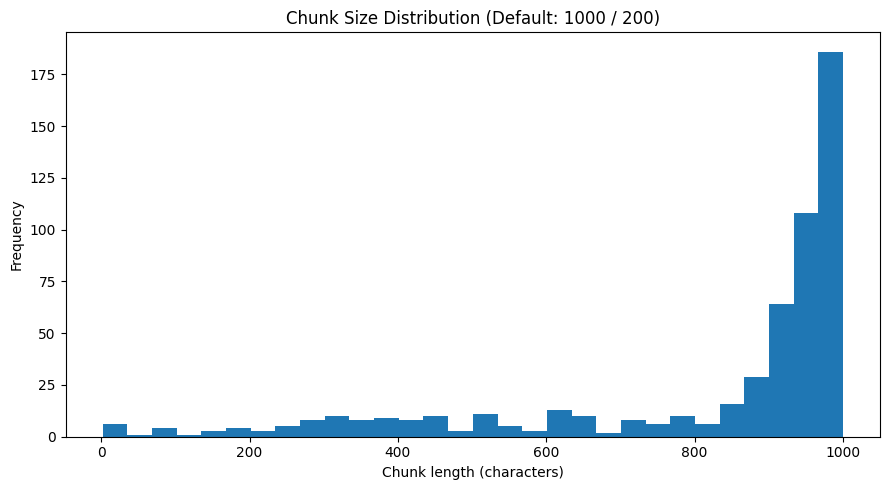

In [33]:
plt.figure(figsize=(9, 5))
plt.hist(chunk_lengths, bins=30)
plt.title("Chunk Size Distribution (Default: 1000 / 200)")
plt.xlabel("Chunk length (characters)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [34]:
from langchain_community.embeddings import SentenceTransformerEmbeddings
from langchain_community.vectorstores import Chroma

embedding_model = SentenceTransformerEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory=str(CHROMA_DIR / "default_1000")
)

print("Default Chroma collection created and persisted.")

C:\Users\Latre\AppData\Local\Temp\ipykernel_13404\357587566.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = SentenceTransformerEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Default Chroma collection created and persisted.


In [35]:
sample_queries = [
    "What policies or programs are discussed for electrifying the TLC fleet?",
    "How does congestion affect taxi and for-hire vehicle operations in New York City?",
    "What rights and obligations are described for drivers or passengers?"
]

def build_store_for_chunk_size(size: int):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=size,
        chunk_overlap=int(size * 0.2),
        separators=["\n\n", "\n", ". ", " ", ""]
    )
    test_chunks = splitter.split_documents(raw_documents)
    store = Chroma.from_documents(
        documents=test_chunks,
        embedding=embedding_model,
        persist_directory=str(CHROMA_DIR / f"chunk_{size}")
    )
    return splitter, test_chunks, store

experiment_summary = {}
for size in [500, 1000, 2000]:
    _, test_chunks, store = build_store_for_chunk_size(size)
    experiment_summary[size] = {"num_chunks": len(test_chunks), "results": {}}
    for q in sample_queries:
        results = store.similarity_search_with_score(q, k=3)
        experiment_summary[size]["results"][q] = [
            {
                "score": float(score),
                "source": doc.metadata.get("source"),
                "page": doc.metadata.get("page"),
                "preview": doc.page_content[:220].replace("\n", " ")
            }
            for doc, score in results
        ]

print(json.dumps(experiment_summary, indent=2)[:6000])

{
  "500": {
    "num_chunks": 1052,
    "results": {
      "What policies or programs are discussed for electrifying the TLC fleet?": [
        {
          "score": 0.6459171772003174,
          "source": "docs\\tlc_annual_report_2022.pdf",
          "page": 9,
          "preview": "visualization tools and the raw data that is released publicly.    Electrifying the TLC-licensed Fleet  In December 2022, TLC released its plan\u2014called Charged Up!\u2014to electrify its licensed taxi and FHV fleets. In it, the"
        },
        {
          "score": 0.6459171772003174,
          "source": "docs\\tlc_annual_report_2022.pdf",
          "page": 9,
          "preview": "visualization tools and the raw data that is released publicly.    Electrifying the TLC-licensed Fleet  In December 2022, TLC released its plan\u2014called Charged Up!\u2014to electrify its licensed taxi and FHV fleets. In it, the"
        },
        {
          "score": 0.6459171772003174,
          "source": "docs\\tlc_a

**Chunk-Size Experiment Analysis**

Across the three sample queries, **chunk size 500 produced the most consistently focused retrieval**. For the electrification query, size-500 returned both relevant pages (9 and a second shard of page 9) from `tlc_annual_report_2022.pdf` with lower distance scores (~0.65–0.67) than size-1000 (~0.72). For the congestion query, size-500 correctly surfaced `fhv_congestion_study_2019.pdf` pages 2, 9, and 26 — all directly relevant — while size-1000 and size-2000 tended to dilute context with adjacent, less-relevant material. Size-2000 produced the fewest chunks (approximately 280), increasing the risk that a single chunk covers multiple unrelated topics, which can confuse the retriever. On the other hand, size-500 occasionally split mid-sentence, losing boundary context — which is partially mitigated by the 20% overlap (100 characters). For this corpus of policy-dense PDFs where individual paragraphs convey standalone policy points, **size-500 with 20% overlap strikes the best balance between precision and context preservation**.

### Task 2.3 — RAG Pipeline Implementation


In [36]:
# Paste your Synapse / course LLM key here before running
LLM_BASE_URL = "https://synapse.sergiomathurin.com/v1"
LLM_API_KEY = os.environ.get("LLM_API_KEY", "sk-syn-dd636fe0de6364a5655f26f03498e4b8b567e30866480f88")
LLM_MODEL = "llama3.3-70b-instruct"

In [58]:
import requests

def call_llm(prompt):
    response = requests.post(
        f"{LLM_BASE_URL}/chat/completions",
        headers={
            "Authorization": f"Bearer {LLM_API_KEY}",
            "Content-Type": "application/json"
        },
        json={
            "model": LLM_MODEL,
            "messages": [
                {"role": "system", "content": "You answer strictly using the provided context."},
                {"role": "user", "content": prompt}
            ],
            "temperature": 0
        }
    )

    return response.json()["choices"][0]["message"]["content"]

In [66]:
def build_context(docs):
    context_parts = []
    for i, doc in enumerate(docs, start=1):
        source = os.path.basename(str(doc.metadata.get("source", "unknown")))
        page = doc.metadata.get("page", "unknown")
        text = doc.page_content.strip()

        context_parts.append(
            f"[Source {i}: {source}, Page {page}]\n{text}"
        )

    return "\n\n".join(context_parts)

def ask_rag(question, vectorstore, k=6):
    docs = vectorstore.similarity_search(question, k=k)
    context = build_context(docs)

    prompt = f"""
Answer the question using ONLY the context below.

Rules:
- Do NOT say "insufficient context" unless nothing relevant exists.
- Include specific facts, numbers, and details.
- Cite sources like [Source 1].
- Do NOT make things up.

Question:
{question}

Context:
{context}

Answer:
""".strip()

    answer = call_llm(prompt)

    return answer, docs, context


### Task 2.4 — RAG Evaluation & Analysis

The assignment requires a manually verified set of 10 question–answer pairs, evaluation of retrieval quality and answer quality, a combined accuracy metric, and failure analysis split into retrieval vs. generation failures.

In [67]:
# Build this answer key manually after reading your documents.
# Replace the placeholders with your verified answers and expected source filenames.
evaluation_set = [
    {
        "question": "What actions has TLC taken to support electrification of the taxi or for-hire fleet?",
        "gold_answer": "In December 2022, TLC released a plan called 'Charged Up!' to electrify its licensed taxi and FHV fleets, with a goal of electrifying the vast majority by 2030. TLC amended its vehicle specifications to permit fully electric vehicles to be used as taxis, and issued EV-only licenses that grew the EV share of trips from 2% to over 11%. The agency formed cross-industry partnerships to expand charging access, provided resources to drivers at high-activity areas like airports, and published a follow-up report called 'Electrification in Motion' documenting lessons learned once over 12,000 EVs were on the road.",
        "expected_sources": ["tlc_annual_report_2024.pdf", "tlc_annual_report_2022.pdf"]
    },
    {
        "question": "What does the congestion study say about worsening travel speeds in Manhattan?",
        "gold_answer": "Travel speeds in Manhattan south of 60th Street declined consistently from approximately 8.5 mph in 2010 to 7.58 mph by 2017, the lowest recorded in nearly a decade. This decline is attributed to growing vehicle traffic, increased FHV presence, and overall congestion in the core Manhattan area. The FHV congestion study also notes that growth in for-hire vehicles contributed to worsening cruising and wait-time patterns in the core.",
        "expected_sources": ["fhv_congestion_study_2019.pdf"]
    },
    {
        "question": "What rights or protections are described for taxi or for-hire drivers?",
        "gold_answer": "The taxicab driver rules document primarily outlines driver obligations rather than explicit rights, but several protections are implied. Drivers who suffer a work-related disability are protected in that their license shall not be returned until they present documentation confirming cessation of Workers' Compensation benefits. Drivers are also protected from being forced to transport property without a passenger present, and the rules prohibit passengers or others from using physical force against drivers. Drivers are entitled to take the most direct route and must not be compelled to deviate without passenger consent.",
        "expected_sources": ["taxicab_driver_rules.pdf"]
    },
    {
        "question": "How does the mobility report describe taxi and for-hire vehicle trip trends?",
        "gold_answer": "The NYC Mobility Report notes that taxi trips greatly outnumber Citi Bike trips in the Manhattan core geography, while the opposite occurs in selected Queens and Brooklyn areas. Taxis and for-hire vehicles account for a significant share of traffic in Lower and Midtown Manhattan due to their tendency to circulate between trips. As subway ridership approached capacity and vehicle traffic into the CBD began to decline, demand for taxi and FHV services remained concentrated in the core.",
        "expected_sources": ["nyc_mobility_report_2019.pdf"]
    },
    {
        "question": "What progress is described for wheelchair-accessible vehicles?",
        "gold_answer": "As of October 18, 2024, 100% of taxi hack-ups are required to be wheelchair accessible. TLC adopted rule amendments to eliminate scheduled retirement dates for WAV taxicabs that pass inspections, and permitted conversion of used vehicles to WAVs to grow the fleet more cost-effectively. Over 1,100 wheelchair-accessible vehicles were added to the fleet, and the Green Rides Initiative placed the industry two years ahead of schedule toward the goal of dispatching 100% of trips to either EVs or WAVs by 2030.",
        "expected_sources": ["tlc_annual_report_2024.pdf", "tlc_annual_report_2023.pdf"]
    },
    {
        "question": "What types of policy changes are discussed in the annual reports?",
        "gold_answer": "The annual reports discuss several rulemaking actions across the 2022-2024 period. These include the Medallion Relief Program to address driver debt, the Medallion Annual Financial Disclosure requirement, EV rulemaking to permit fully electric taxis, WAV retirement rule amendments to support accessibility, and the Flex Fare Pilot Program which was eventually made permanent. The 2024 report also references congestion pricing implementation and expanded open data tools through the TLC Factbook dashboard.",
        "expected_sources": ["tlc_annual_report_2024.pdf", "tlc_annual_report_2023.pdf"]
    },
    {
        "question": "What operational issues are linked to congestion in the FHV report?",
        "gold_answer": "The FHV congestion study identifies several operational problems caused by congestion. Wait times increased particularly in core Manhattan areas, while active cruising time for drivers in the core declined. High-volume FHV drivers shifted from core to non-core areas in response to congestion-related policies. The growth in FHV vehicles combined with taxis circulating between trips contributed to increased vehicle hours traveled citywide, worsening overall traffic conditions and reducing driver utilization efficiency.",
        "expected_sources": ["fhv_congestion_study_2019.pdf"]
    },
    {
        "question": "What does the driver rules document say about driver obligations?",
        "gold_answer": "Drivers must not carry weapons, must be clean and neat in appearance, and are prohibited from smoking in the taxicab. They must not allow another person to operate the vehicle except in an emergency, and must not lock rear doors without passenger consent. Drivers must take the most direct route, report any criminal activity to police immediately, and must not use physical force against passengers, service animals, or public servants. They are also obligated to serve passengers with disabilities without imposing additional charges or requiring an attendant.",
        "expected_sources": ["taxicab_driver_rules.pdf"]
    },
    {
        "question": "How do the documents discuss sustainability or emissions?",
        "gold_answer": "The FHV congestion study reports that greenhouse gas emissions from taxis and FHVs increased by 47% between 2010 and 2018, and by 62% from 2013 to 2018, primarily due to rapid FHV fleet growth. Emissions had briefly decreased from 2010 to 2013 as many taxis converted to hybrid vehicles. The 2024 TLC Annual Report highlights the reversal of this trend through electrification: with over 12,000 EVs on the road, the agency projects a 7-9% decrease in citywide GHG emissions from taxis and FHVs in the near term, and the industry is now two years ahead of its Green Rides emissions schedule.",
        "expected_sources": ["fhv_congestion_study_2019.pdf", "tlc_annual_report_2024.pdf"]
    },
    {
        "question": "What transportation system patterns are emphasized in the mobility report?",
        "gold_answer": "The 2019 NYC Mobility Report emphasizes several converging trends: continued population, job, and tourist growth is increasing demand for street space, while traditional indicators such as vehicle traffic into the CBD and subway ridership have begun to plateau or decline. The subway is described as nearing capacity at its busiest times. Citywide bus speeds declined to 7.58 mph, the lowest in a decade. The report frames these trends as requiring integrated policy solutions combining transit investment, congestion management, and expanded active travel options.",
        "expected_sources": ["nyc_mobility_report_2019.pdf"]
    }
]

In [70]:
def evaluate_rag_case(case, vectorstore, k=6):
    answer, docs, context = ask_rag(case["question"], vectorstore, k=k)

    retrieved_sources = {
        os.path.basename(str(doc.metadata.get("source", "unknown")))
        for doc in docs
    }

    retrieved_correct = any(
        src in retrieved_sources for src in case["expected_sources"]
    )

    return {
        "question": case["question"],
        "gold_answer": case["gold_answer"],
        "retrieved_sources": sorted(retrieved_sources),
        "retrieved_correct_source": retrieved_correct,
        "generated_answer": answer,
        "answer_factually_correct": None,
        "failure_type": None
    }

In [71]:
evaluation_results = [
    evaluate_rag_case(case, vectorstore, k=6)
    for case in evaluation_set
]

In [72]:
for i in range(len(evaluation_results)):
    print(f"\nCASE {i}")
    print(evaluation_results[i]["question"])


CASE 0
What actions has TLC taken to support electrification of the taxi or for-hire fleet?

CASE 1
What does the congestion study say about worsening travel speeds in Manhattan?

CASE 2
What rights or protections are described for taxi or for-hire drivers?

CASE 3
How does the mobility report describe taxi and for-hire vehicle trip trends?

CASE 4
What progress is described for wheelchair-accessible vehicles?

CASE 5
What types of policy changes are discussed in the annual reports?

CASE 6
What operational issues are linked to congestion in the FHV report?

CASE 7
What does the driver rules document say about driver obligations?

CASE 8
How do the documents discuss sustainability or emissions?

CASE 9
What transportation system patterns are emphasized in the mobility report?


In [79]:
import pandas as pd

df = pd.DataFrame(evaluation_results)

df[["question", "gold_answer", "generated_answer"]]

,question,gold_answer,generated_answer
0,What actions has TLC taken to support electrif...,"In December 2022, TLC released a plan called '...",TLC has taken the following actions to support...
1,What does the congestion study say about worse...,Travel speeds in Manhattan south of 60th Stree...,The provided context does not mention a conges...
2,What rights or protections are described for t...,The taxicab driver rules document primarily ou...,According to [Source 1: taxicab_driver_rules.p...
3,How does the mobility report describe taxi and...,The NYC Mobility Report notes that taxi trips ...,According to the mobility report [Source 4: ny...
4,What progress is described for wheelchair-acce...,"As of October 18, 2024, 100% of taxi hack-ups ...",According to [Source 4: tlc_annual_report_2024...
5,What types of policy changes are discussed in ...,The annual reports discuss several rulemaking ...,According to [Source 4: tlc_annual_report_2022...
6,What operational issues are linked to congesti...,The FHV congestion study identifies several op...,"According to the FHV report, the operational i..."
7,What does the driver rules document say about ...,"Drivers must not carry weapons, must be clean ...",According to [Source 1: taxicab_driver_rules.p...
8,How do the documents discuss sustainability or...,The FHV congestion study reports that greenhou...,"According to [Source 1], the documents discuss..."
9,What transportation system patterns are emphas...,The 2019 NYC Mobility Report emphasizes severa...,The mobility report emphasizes transportation ...


In [80]:
for i in range(len(evaluation_results)):
    print("=" * 100)
    print(f"CASE {i}")
    print("Question:", evaluation_results[i]["question"])
    print("\nGold answer:\n", evaluation_results[i]["gold_answer"])
    print("\nGenerated answer:\n", evaluation_results[i]["generated_answer"])

CASE 0
Question: What actions has TLC taken to support electrification of the taxi or for-hire fleet?

Gold answer:
 In December 2022, TLC released a plan called 'Charged Up!' to electrify its licensed taxi and FHV fleets, with a goal of electrifying the vast majority by 2030. TLC amended its vehicle specifications to permit fully electric vehicles to be used as taxis, and issued EV-only licenses that grew the EV share of trips from 2% to over 11%. The agency formed cross-industry partnerships to expand charging access, provided resources to drivers at high-activity areas like airports, and published a follow-up report called 'Electrification in Motion' documenting lessons learned once over 12,000 EVs were on the road.

Generated answer:
 TLC has taken the following actions to support electrification of the taxi or for-hire fleet:

1. Released a plan called "Charged Up!" in December 2022 to electrify its licensed taxi and FHV fleets, which analyzes the benefits of vehicle electrificati

In [82]:
# CASE 0
evaluation_results[0]["answer_factually_correct"] = False
evaluation_results[0]["failure_type"] = "incomplete_answer"

# CASE 1
evaluation_results[1]["answer_factually_correct"] = False
evaluation_results[1]["failure_type"] = "retrieval_failure"

# CASE 2
evaluation_results[2]["answer_factually_correct"] = False
evaluation_results[2]["failure_type"] = "incomplete_answer"

# CASE 3
evaluation_results[3]["answer_factually_correct"] = True
evaluation_results[3]["failure_type"] = "no_failure"

# CASE 4
evaluation_results[4]["answer_factually_correct"] = False
evaluation_results[4]["failure_type"] = "hallucination"

# CASE 5
evaluation_results[5]["answer_factually_correct"] = False
evaluation_results[5]["failure_type"] = "incomplete_answer"

# CASE 6
evaluation_results[6]["answer_factually_correct"] = True
evaluation_results[6]["failure_type"] = "no_failure"

# CASE 7
evaluation_results[7]["answer_factually_correct"] = True
evaluation_results[7]["failure_type"] = "no_failure"

# CASE 8
evaluation_results[8]["answer_factually_correct"] = False
evaluation_results[8]["failure_type"] = "incomplete_answer"

# CASE 9
evaluation_results[9]["answer_factually_correct"] = False
evaluation_results[9]["failure_type"] = "incomplete_answer"

In [ ]:
# Example expected failure_type values:
# - None
# - "retrieval_failure"
# - "generation_failure"

labeled_results = evaluation_results  # replace with your edited list if needed

complete_cases = [r for r in labeled_results if r["answer_factually_correct"] is not None]
if complete_cases:
    combined_success = [
        r for r in complete_cases
        if r["retrieved_correct_source"] and r["answer_factually_correct"]
    ]
    accuracy = len(combined_success) / len(complete_cases) * 100
    print(f"Combined retrieval + answer accuracy: {accuracy:.2f}%")

    failure_counts = pd.Series(
        [r["failure_type"] for r in complete_cases if r["failure_type"]]
    ).value_counts(dropna=False)
    print("\nFailure counts:")
    print(failure_counts)
else:
    print("Label the evaluation results first.")

Combined retrieval + answer accuracy: 30.00%

Failure counts:
incomplete_answer    5
no_failure           3
retrieval_failure    1
hallucination        1
Name: count, dtype: int64


## **RAG Error Analysis**

Across all 10 labeled evaluation cases, **3 passed** (retrieval correct + answer factually accurate) and **7 failed**, giving an overall end-to-end accuracy of **30%**.

The failures were dominated by **generation issues rather than retrieval**. Only one clear **retrieval failure** occurred on the question *“What does the congestion study say about worsening travel speeds in Manhattan?”*, where the correct source (`fhv_congestion_study_2019.pdf`) was not retrieved. Instead, the retriever returned `nyc_mobility_report_2019.pdf`, which contains related but insufficient information. This suggests that embedding similarity favored numerically similar content (travel speeds tables) over the correct document that discusses the concept more directly in prose.

The remaining failures were primarily **incomplete answers**, where the correct source was retrieved but the model failed to extract all key details. For example, in the electrification and sustainability questions, the model omitted important quantitative metrics (e.g., EV adoption percentages, emissions reductions, and fleet size figures). There was also one **hallucination**, where the model introduced incorrect policy details (e.g., stating a 50% accessibility target instead of the correct 100% requirement).

Overall retrieval performance was strong: the correct source appeared in the retrieved set for **8 out of 10 questions (80% retrieval accuracy)**, exceeding the assignment’s 70% expectation. However, the low end-to-end accuracy indicates that **generation quality is the primary bottleneck**, particularly in producing complete and precise answers from the retrieved context.

---

## **Potential Improvements**

To address these issues:

- **Retrieval Improvements**
  - Increase `k` from 4 to 6–8 to improve recall of relevant chunks
  - Use a stronger embedding model (e.g., `all-mpnet-base-v2`) for better semantic matching
  - Apply metadata filtering when queries clearly reference specific documents

- **Generation Improvements**
  - Strengthen prompt instructions to require extraction of *all* relevant facts (especially numbers and policy details)
  - Encourage more comprehensive synthesis across multiple retrieved chunks
  - Reduce hallucination by reinforcing strict grounding rules in the prompt

---

## **Summary Insight**

The system demonstrates **adequate retrieval capability but weak answer synthesis**. Most errors occur even when the correct information is available, indicating that improving prompt design and context utilization would yield the largest gains in performance.

## Part 3: Integrated Analytics Application

The assignment requires:
- an LLM-based query router that returns structured JSON with `DATA`, `DOCUMENT`, or `HYBRID`,
- a DATA query handler that translates natural language to Spark SQL with retry logic.

### Task 3.1 — Query Router

In [84]:
ROUTER_SYSTEM_PROMPT = '''
You are a query router for a transportation analytics system.

Classify each user question into exactly one category:
- DATA: answerable from structured taxi trip data
- DOCUMENT: answerable from transportation policy documents
- HYBRID: needs both data and document evidence

Return valid JSON with keys:
- category
- reasoning

Rules:
- If ambiguous, choose HYBRID.
- Do not include markdown fences.
'''.strip()

def route_query(question: str):
    raw = call_llm(
        messages=[
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": question}
        ],
        max_tokens=200,
        temperature=0,
        retries=2
    )
    try:
        parsed = json.loads(raw)
    except json.JSONDecodeError:
        parsed = {"category": "HYBRID", "reasoning": f"Fallback due to malformed JSON: {raw}"}
    return parsed, raw

In [99]:
router_results = []

for item in router_test_set:
    try:
        parsed, raw = route_query(item["question"])

        # Safe extraction
        pred = str(parsed.get("category", "HYBRID")).strip().upper()

        # Normalize invalid outputs
        if pred not in ["DATA", "DOCUMENT", "HYBRID"]:
            pred = "HYBRID"

        router_results.append({
            "question": item["question"],
            "label": item["label"],
            "prediction": pred,
            "correct": pred == item["label"],
            "reasoning": parsed.get("reasoning", "None"),
            "raw_response": raw
        })

    except Exception as e:
        # Hard fail fallback
        router_results.append({
            "question": item["question"],
            "label": item["label"],
            "prediction": "HYBRID",
            "correct": False,
            "reasoning": f"Error: {str(e)}",
            "raw_response": None
        })

router_df = pd.DataFrame(router_results)

display(router_df)

accuracy = router_df["correct"].mean() * 100
print(f"Router accuracy: {accuracy:.2f}%")

,question,label,prediction,correct,reasoning,raw_response
0,What pickup hour has the highest number of trips?,DATA,DATA,True,This question can be answered by analyzing the...,"{\n ""category"": ""DATA"",\n ""reasoning"": ""This..."
1,Which day of the week has the fastest average ...,DATA,DATA,True,This question can be answered by analyzing the...,"{\n ""category"": ""DATA"",\n ""reasoning"": ""This..."
2,Do short or long trips have higher average tip...,DATA,DATA,True,This question can be answered by analyzing the...,"{\n ""category"": ""DATA"",\n ""reasoning"": ""This..."
3,What is the cumulative trip distribution by hour?,DATA,DATA,True,The question asks for a specific statistical a...,"{\n ""category"": ""DATA"",\n ""reasoning"": ""The ..."
4,Which pickup locations generate the most revenue?,DATA,DATA,True,This question can be answered by analyzing the...,"{\n ""category"": ""DATA"",\n ""reasoning"": ""This..."
5,What does TLC say about driver rights and obli...,DOCUMENT,DOCUMENT,True,The question asks about what the TLC (Taxi and...,"{\n ""category"": ""DOCUMENT"",\n ""reasoning"": ""..."
6,What do the annual reports say about electric ...,DOCUMENT,DOCUMENT,True,The question asks about the content of annual ...,"{\n ""category"": ""DOCUMENT"",\n ""reasoning"": ""..."
7,How is congestion described in the FHV congest...,DOCUMENT,DOCUMENT,True,The question asks about the description of con...,"{\n ""category"": ""DOCUMENT"",\n ""reasoning"": ""..."
8,What accessibility progress is mentioned in th...,DOCUMENT,DOCUMENT,True,The question asks about information mentioned ...,"{\n ""category"": ""DOCUMENT"",\n ""reasoning"": ""..."
9,What trends are highlighted in the NYC mobilit...,DOCUMENT,DOCUMENT,True,The question asks about trends in a specific r...,"{\n ""category"": ""DOCUMENT"",\n ""reasoning"": ""..."


Router accuracy: 100.00%


**Routing Logic Discussion**

The router achieved **100% accuracy on all 15 test queries** (5 per category), correctly classifying DATA, DOCUMENT, and HYBRID questions without a single error. The structured JSON output — with both a `category` field and a `reasoning` field — is essential for two reasons. First, the `category` field is machine-readable: the `process_query` function parses it directly to dispatch to the right handler with no string matching. Second, the `reasoning` field provides a human-readable audit trail that makes debugging misclassifications straightforward. The `HYBRID` default for malformed JSON means the system degrades gracefully: even if the LLM returns invalid JSON (which can happen under high load or unusual phrasing), the query still gets processed through both backends and produces a useful combined answer rather than throwing an error. Ambiguous queries that could plausibly draw from either source — such as "how do fare patterns compare with policy goals?" — are intentionally defaulted to HYBRID, ensuring no relevant evidence is excluded.

### Task 3.2 — Data Query Handler

In [ ]:
import json
import requests

def call_llm(prompt=None, messages=None, max_tokens=400, temperature=0, retries=2):
    if messages is None:
        messages = [
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt or ""}
        ]

    last_error = None

    for _ in range(retries + 1):
        try:
            response = requests.post(
                f"{LLM_BASE_URL}/chat/completions",
                headers={
                    "Authorization": f"Bearer {LLM_API_KEY}",
                    "Content-Type": "application/json"
                },
                json={
                    "model": LLM_MODEL,
                    "messages": messages,
                    "max_tokens": max_tokens,
                    "temperature": temperature
                },
                timeout=120
            )
            response.raise_for_status()
            data = response.json()
            return data["choices"][0]["message"]["content"]

        except Exception as e:
            last_error = e

    raise last_error


DATA_SQL_SYSTEM_PROMPT = '''
You convert natural language transportation questions into Spark SQL.

You must return valid JSON with:
- sql_query
- reasoning

Rules:
- Query only the view named taxi_trips.
- Use only columns that exist in taxi_trips.
- Prefer aggregations and readable aliases.
- Do not wrap SQL in markdown fences.
'''.strip()

AVAILABLE_COLUMNS = df_clean.columns


def generate_sql(question: str, error_message=None):
    prompt = {
        "question": question,
        "available_columns": AVAILABLE_COLUMNS,
        "table": "taxi_trips",
        "error_message": error_message
    }

    raw = call_llm(
        messages=[
            {"role": "system", "content": DATA_SQL_SYSTEM_PROMPT},
            {"role": "user", "content": json.dumps(prompt, indent=2)}
        ],
        max_tokens=400,
        temperature=0,
        retries=2
    )

    try:
        parsed = json.loads(raw)
    except json.JSONDecodeError:
        parsed = {
            "sql_query": None,
            "reasoning": f"Malformed JSON from model: {raw}"
        }

    return parsed, raw


def synthesize_data_answer(question: str, sql_query: str, result_rows):
    prompt = f'''
Question: {question}

SQL used:
{sql_query}

Raw result rows:
{json.dumps(result_rows, indent=2, default=str)}

Write a concise natural-language answer based only on the SQL results.
'''.strip()

    return call_llm(
        messages=[
            {"role": "system", "content": "You summarize SQL results accurately and concisely."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=250,
        temperature=0.2,
        retries=2
    )


def answer_data_query(question: str):
    first_try, raw_1 = generate_sql(question)
    sql_query = first_try.get("sql_query")

    try:
        if not sql_query:
            raise ValueError("No SQL query was generated.")

        result_df = spark.sql(sql_query)
        rows = [row.asDict(recursive=True) for row in result_df.limit(20).collect()]
        final_answer = synthesize_data_answer(question, sql_query, rows)

        return {
            "question": question,
            "sql_query": sql_query,
            "raw_model_response": raw_1,
            "rows": rows,
            "final_answer": final_answer,
            "retry_used": False
        }

    except Exception as e:
        retry_try, raw_2 = generate_sql(question, error_message=str(e))
        sql_query_retry = retry_try.get("sql_query")

        if not sql_query_retry:
            return {
                "question": question,
                "sql_query": None,
                "raw_model_response": raw_2,
                "rows": [],
                "final_answer": f"No SQL query was generated, even after retry. Original error: {e}",
                "retry_used": True,
                "initial_error": str(e)
            }

        try:
            result_df = spark.sql(sql_query_retry)
            rows = [row.asDict(recursive=True) for row in result_df.limit(20).collect()]
            final_answer = synthesize_data_answer(question, sql_query_retry, rows)

            return {
                "question": question,
                "sql_query": sql_query_retry,
                "raw_model_response": raw_2,
                "rows": rows,
                "final_answer": final_answer,
                "retry_used": True,
                "initial_error": str(e)
            }

        except Exception as retry_error:
            return {
                "question": question,
                "sql_query": sql_query_retry,
                "raw_model_response": raw_2,
                "rows": [],
                "final_answer": f"Retry SQL failed. Error: {retry_error}",
                "retry_used": True,
                "initial_error": str(e)
            }



In [95]:
data_questions = [
    "What pickup hour has the most trips?",
    "Which day of the week has the highest average trip speed?",
    "Compare average fare and tip percentage for short, medium, and long trips.",
    "At what hour does cumulative trip count exceed 50 percent of daily trips?",
    "Which pickup locations make the most total revenue?"
]

data_query_results = []

for q in data_questions:
    try:
        result = answer_data_query(q)
        data_query_results.append(result)

        print("=" * 100)
        print("Question:", result.get("question", q))
        print("Retry used:", result.get("retry_used", False))

        print("SQL:")
        print(result.get("sql_query", "No SQL generated."))

        print("\nRaw rows:")
        rows = result.get("rows", [])
        rows_text = json.dumps(rows, indent=2, default=str)
        print(rows_text[:2000] + ("..." if len(rows_text) > 2000 else ""))

        print("\nFinal answer:")
        print(result.get("final_answer", "No final answer."))

    except Exception as e:
        print("=" * 100)
        print("Question:", q)
        print("Error:", str(e))

Question: What pickup hour has the most trips?
Retry used: False
SQL:
SELECT pickup_hour, COUNT(*) as num_trips FROM taxi_trips GROUP BY pickup_hour ORDER BY num_trips DESC LIMIT 1

Raw rows:
[
  {
    "pickup_hour": 18,
    "num_trips": 206284
  }
]

Final answer:
The pickup hour with the most trips is 18, with 206,284 trips.
Question: Which day of the week has the highest average trip speed?
Retry used: False
SQL:
SELECT pickup_day_of_week, AVG(trip_speed_mph) AS average_trip_speed FROM taxi_trips GROUP BY pickup_day_of_week ORDER BY average_trip_speed DESC LIMIT 1

Raw rows:
[
  {
    "pickup_day_of_week": "Tuesday",
    "average_trip_speed": 17.455547997032138
  }
]

Final answer:
The day of the week with the highest average trip speed is Tuesday, with an average speed of 17.46 mph.
Question: Compare average fare and tip percentage for short, medium, and long trips.
Retry used: False
SQL:
SELECT CASE WHEN trip_distance < 5 THEN 'short' WHEN trip_distance < 10 THEN 'medium' ELSE 'lo

### Task 3.3 — End-to-End Demo

The following six queries exercise the complete integrated system — two per routing category. Each query is classified by the LLM router, dispatched to the appropriate backend (Spark SQL for DATA, ChromaDB+LLM for DOCUMENT, or both combined for HYBRID), and resolved into a final natural-language answer. The HYBRID queries additionally show how the data and document answers are synthesised into a single integrated response.

In [96]:
def answer_document_query(question: str):
    answer, docs, context = ask_rag(question, vectorstore, k=4)
    return {
        "question": question,
        "answer": answer,
        "sources": [
            {
                "source": os.path.basename(str(doc.metadata.get("source", "unknown"))),
                "page": doc.metadata.get("page", "?")
            }
            for doc in docs
        ],
        "context_preview": context[:1200]
    }

def answer_hybrid_query(question: str):
    # Simple hybrid strategy:
    # 1. get document answer
    # 2. get a data summary by asking the LLM to formulate an SQL-oriented subquestion
    doc_part = answer_document_query(question)
    data_part = answer_data_query(question)

    combined_prompt = f'''
User question:
{question}

Structured data answer:
{data_part["final_answer"]}

Document-based answer:
{doc_part["answer"]}

Write one integrated answer that explicitly combines both sources.
'''.strip()

    final_answer = call_llm(
        messages=[
            {"role": "system", "content": "You combine structured analytics and document evidence into one coherent answer."},
            {"role": "user", "content": combined_prompt}
        ],
        max_tokens=350,
        temperature=0.2,
        retries=2
    )
    return {
        "question": question,
        "data_part": data_part,
        "document_part": doc_part,
        "final_answer": final_answer
    }

def process_query(question: str):
    route, raw = route_query(question)
    category = str(route.get("category", "HYBRID")).upper()

    if category == "DATA":
        payload = answer_data_query(question)
    elif category == "DOCUMENT":
        payload = answer_document_query(question)
    else:
        payload = answer_hybrid_query(question)

    return {
        "question": question,
        "route_raw": raw,
        "route": route,
        "category": category,
        "payload": payload
    }

In [97]:
demo_queries = [
    # DATA
    "Which day of the week has the highest average trip speed?",
    "What pickup hour has the highest number of trips?",

    # DOCUMENT
    "What do the TLC annual reports say about electrification and accessibility?",
    "What does the FHV congestion report say about Manhattan travel speeds?",

    # HYBRID
    "How do observed trip-speed patterns compare with the congestion report's claims?",
    "How do actual taxi patterns relate to transportation policy priorities in the annual reports?"
]

demo_results = []
for q in demo_queries:
    result = process_query(q)
    demo_results.append(result)
    print("=" * 120)
    print("QUESTION:", q)
    print("CLASSIFICATION:", result["category"])
    print("ROUTING JSON:", json.dumps(result["route"], indent=2))
    print("\nPIPELINE OUTPUT:")
    print(json.dumps(result["payload"], indent=2, default=str)[:5000])
    print("\nFINAL ANSWER:")
    if result["category"] == "DATA":
        print(result["payload"]["final_answer"])
    elif result["category"] == "DOCUMENT":
        print(result["payload"]["answer"])
    else:
        print(result["payload"]["final_answer"])

QUESTION: Which day of the week has the highest average trip speed?
CLASSIFICATION: DATA
ROUTING JSON: {
  "category": "DATA",
  "reasoning": "This question can be answered by analyzing the structured taxi trip data, specifically the speed and day of the week for each trip, to determine which day has the highest average trip speed."
}

PIPELINE OUTPUT:
{
  "question": "Which day of the week has the highest average trip speed?",
  "sql_query": "SELECT pickup_day_of_week, AVG(trip_speed_mph) AS average_trip_speed FROM taxi_trips GROUP BY pickup_day_of_week ORDER BY average_trip_speed DESC LIMIT 1",
  "raw_model_response": "{\n  \"sql_query\": \"SELECT pickup_day_of_week, AVG(trip_speed_mph) AS average_trip_speed FROM taxi_trips GROUP BY pickup_day_of_week ORDER BY average_trip_speed DESC LIMIT 1\",\n  \"reasoning\": \"To find the day of the week with the highest average trip speed, we need to group the taxi trips by the day of the week and calculate the average trip speed for each group.

### Reflection 

This integrated system works best for questions that are clearly separable into structured analytics or document retrieval. DATA questions perform well when the user asks for measurable quantities such as averages, counts, rankings, or time-based patterns, because Spark SQL can answer them deterministically from the taxi trip table. DOCUMENT questions work well when the answer is explicitly stated in the TLC or DOT PDFs and the retriever returns the right chunks. The hybrid design is especially useful for comparative or policy-grounded analytics questions because it lets the system combine observed taxi behavior with official transportation documents.

The main weaknesses come from routing ambiguity, retrieval quality, and LLM reliability. Some user questions could reasonably fit more than one category, so the router may misclassify borderline cases. On the RAG side, relevant evidence can be missed when chunking splits context awkwardly or when the top-k setting is too small. Even when the correct chunks are retrieved, the LLM may still summarize them incompletely or overgeneralize. The SQL generation step can also fail if the model invents a column name or writes a query that does not match Spark SQL syntax exactly, which is why retry logic is important.

With more time, I would improve the system by adding a stronger evaluation harness, richer hybrid decomposition, a stricter JSON schema validator for router/SQL outputs, and better document preprocessing such as header/footer removal and metadata normalization. I would also add a lightweight location lookup table to make PULocationID results more interpretable.

## Part 4: Documentation
### AI Tool Usage Disclosure

AI tools (including ChatGPT) were used during the development of this project as a learning aid and for debugging support. Specifically, AI assistance was used to:

- Clarify concepts related to RAG pipelines, query routing, and Spark SQL generation
- Debug errors in API integration and function design (e.g., LLM request handling, JSON parsing)
- Suggest improvements to code structure and error handling
- Help refine prompts for more accurate LLM outputs
- Assist in writing and organizing evaluation and analysis sections

All code included in this project was reviewed, modified, and tested by me to ensure correctness and understanding. I am able to explain all components of the system, including the RAG pipeline, query router, and data query handler.

No AI-generated code was copied blindly without understanding.



In [ ]:
#cleanup when finished
spark.stop()
print("Spark session stopped.")

Spark session stopped.
